#  Group 2 Sentiment Analysis: GRU Architecture with one to many ID to Contents

###  **DSBA 6165: AI & Deep Learning**
### Group Member: Paul Berlin, Anders Pierson, Roberto Panameno

## Proc3 Goal

The dataset has been concatenated so that there is one comment per ID. The model has been significantly modified to address the longer text entries, while still using a GRU architecture.

## Uploading Training and Validation Dataset

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importing Dataset
datatot = pd.read_csv('/content/twitter_combined.csv')

In [ ]:
datatot.head(5)

,tweet_id,entity,sentiment,tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## Data Preprocessing

In [ ]:
import re
import pandas as pd

def clean_text(text):
    text = str(text) # Ensure the input is a string
    text = text.lower() # Convert text to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove user mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters, keeping only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Replace multiple spaces with a single space and strip leading/trailing spaces
    return text

# Group by tweet_id and other relevant identifiers (entity, sentiment) and concatenate the original 'tweet_content' for each unique group.
grouped_datatot = datatot.groupby(['tweet_id', 'entity', 'sentiment'])['tweet_content'].apply(lambda x: ' '.join(x.astype(str))).reset_index()

# Apply the clean_text function to the newly concatenated 'tweet_content'
grouped_datatot['cleaned_tweet_content'] = grouped_datatot['tweet_content'].apply(clean_text)

# Replace the original datatot DataFrame with this new, grouped and cleaned version.
datatot = grouped_datatot

print("Text cleaning and concatenation complete. Dataframe now grouped by 'tweet_id'.")
print("Displaying the first 5 rows with the new 'cleaned_tweet_content' column:")
datatot.head()

Text cleaning and concatenation complete. Dataframe now grouped by 'tweet_id'.
Displaying the first 5 rows with the new 'cleaned_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...


## Tokenize Text

In [ ]:
datatot['tokenized_tweet_content'] = datatot['cleaned_tweet_content'].apply(lambda x: x.split())

print("Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_tweet_content' column:")
datatot.head()

Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ..."


## Remove Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
print("NLTK stopwords corpus downloaded.")

NLTK stopwords corpus downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

datatot['filtered_tweet_content'] = datatot['tokenized_tweet_content'].apply(remove_stopwords)

print("Stopword removal complete. Displaying the first 5 rows with the new 'filtered_tweet_content' column:")
datatot.head()

Stopword removal complete. Displaying the first 5 rows with the new 'filtered_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t..."


## Lemmatize Text

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK 'wordnet' and 'omw-1.4' corpora downloaded.")

NLTK 'wordnet' and 'omw-1.4' corpora downloaded.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

datatot['lemmatized_tweet_content'] = datatot['filtered_tweet_content'].apply(lemmatize_tokens)

print("Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_tweet_content' column:")
datatot.head()

Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim..."


## Build Vocabulary and Encode Text

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Join the lemmatized tokens back into strings for the tokenizer
datatot['lemmatized_text_string'] = datatot['lemmatized_tweet_content'].apply(lambda x: ' '.join(x))

# Initialize tokenizer, considering a vocabulary size and OOV token
# The num_words parameter determines the maximum number of words to keep, based on word frequency.
# oov_token handles words not found in the vocabulary during text_to_sequence conversion.
tokenizer = Tokenizer(num_words=10000, oov_token='<unk>') # Adjust num_words as needed

# Fit tokenizer on the lemmatized text strings to build the vocabulary
tokenizer.fit_on_texts(datatot['lemmatized_text_string'])

# Convert text to sequences of integers
datatot['encoded_tweet_content'] = tokenizer.texts_to_sequences(datatot['lemmatized_text_string'])

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print("Text encoding complete. Displaying the first 5 rows with the new 'encoded_tweet_content' column:")
datatot.head()

Vocabulary size: 34797
Text encoding complete. Displaying the first 5 rows with the new 'encoded_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content,lemmatized_text_string,encoded_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...",wtf amazon wtf amazon wtf wtf wtf unk wtf,"[167, 42, 167, 42, 167, 167, 167, 55, 167]"
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde...",im really disappointed amazon today ordered ki...,"[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ...",admit sub leak thought cheeky hot lad spending...,"[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal...",probably worst customer service ive deal latel...,"[228, 226, 314, 148, 53, 353, 966, 42, 228, 22..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim...",ive purchased time site time itunes time amazo...,"[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1..."


## Pad Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine the maximum sequence length for padding
# Using the 95th percentile to avoid extremely long sequences affecting all others
sequence_lengths = [len(seq) for seq in datatot['encoded_tweet_content']]
max_sequence_length = int(np.percentile(sequence_lengths, 95)) # Use 95th percentile for max length

# Pad sequences to the chosen maximum length
padded_sequences = pad_sequences(
    datatot['encoded_tweet_content'],
    maxlen=max_sequence_length,
    padding='post', # Pad with zeros at the end
    truncating='post' # Truncate from the end if sequence is longer than maxlen
)

print(f"Maximum sequence length (95th percentile): {max_sequence_length}")
print(f"Shape of padded sequences: {padded_sequences.shape}")

# You can add the padded sequences back to the DataFrame if needed,
# but often they are used directly for model input
datatot['padded_tweet_content'] = list(padded_sequences)

print("Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:")
datatot.head()

Maximum sequence length (95th percentile): 150
Shape of padded sequences: (12447, 150)
Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content,lemmatized_text_string,encoded_tweet_content,padded_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...",wtf amazon wtf amazon wtf wtf wtf unk wtf,"[167, 42, 167, 42, 167, 167, 167, 55, 167]","[167, 42, 167, 42, 167, 167, 167, 55, 167, 0, ..."
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde...",im really disappointed amazon today ordered ki...,"[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328...","[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ...",admit sub leak thought cheeky hot lad spending...,"[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,...","[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal...",probably worst customer service ive deal latel...,"[228, 226, 314, 148, 53, 353, 966, 42, 228, 22...","[228, 226, 314, 148, 53, 353, 966, 42, 228, 22..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim...",ive purchased time site time itunes time amazo...,"[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1...","[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1..."


## Prepare Data for GRU Model


In [ ]:
print("Unique sentiment values:")
print(datatot['sentiment'].value_counts())

Unique sentiment values:
sentiment
Negative      3757
Positive      3472
Neutral       3053
Irrelevant    2165
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'sentiment' column
datatot['encoded_sentiment'] = label_encoder.fit_transform(datatot['sentiment'])

print("Sentiment labels encoded. Displaying the first 5 rows with the new 'encoded_sentiment' column:")
print(datatot[['sentiment', 'encoded_sentiment']].head())

# Also print the mapping of original labels to encoded integers
print("\nMapping of sentiment labels to encoded integers:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

Sentiment labels encoded. Displaying the first 5 rows with the new 'encoded_sentiment' column:
    sentiment  encoded_sentiment
0    Negative                  1
1    Negative                  1
2     Neutral                  2
3    Negative                  1
4  Irrelevant                  0

Mapping of sentiment labels to encoded integers:
Irrelevant: 0
Negative: 1
Neutral: 2
Positive: 3


In [ ]:
from tensorflow.keras.utils import to_categorical

# Apply one-hot encoding to the encoded sentiment labels
y_one_hot = to_categorical(datatot['encoded_sentiment'], num_classes=len(label_encoder.classes_))

print(f"Shape of one-hot encoded sentiment labels (y_one_hot): {y_one_hot.shape}")
print("First 5 one-hot encoded labels:")
print(y_one_hot[:5])

Shape of one-hot encoded sentiment labels (y_one_hot): (12447, 4)
First 5 one-hot encoded labels:
[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Define features (X) as padded sequences and target (y) as one-hot encoded labels
X = np.array(datatot['padded_tweet_content'].tolist()) # Convert list of arrays to a single NumPy array
y = y_one_hot

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (9957, 150)
Shape of X_val: (2490, 150)
Shape of y_train: (9957, 4)
Shape of y_val: (2490, 4)


## Integrate Pre-trained Word Embeddings (GloVe)

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

print("GloVe embeddings downloaded and unzipped.")

--2026-04-09 01:34:56--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-09 01:34:56--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-09 01:34:57--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

## Calculate Class Weights

In [ ]:
import numpy as np

# Load GloVe embeddings into a dictionary
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

# Create an embedding matrix
vocab_size = len(tokenizer.word_index) + 1  # Add 1 for padding/OOV
embedding_dim = 100 # GloVe 100-dimensional vectors

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i >= vocab_size: # Ensure index is within vocab_size
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Found 400000 word vectors.
Embedding matrix shape: (34798, 100)


In [ ]:
from sklearn.utils import class_weight

# Calculate class weights for imbalanced dataset
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_true_labels),
    y=y_true_labels
)
class_weights_dict = dict(enumerate(class_weights))

print("Calculated class weights:")
for i, weight in class_weights_dict.items():
    print(f"Class {i} ({label_encoder.classes_[i]}): {weight:.4f}")

Calculated class weights:
Class 0 (Irrelevant): 1.4376
Class 1 (Negative): 0.8278
Class 2 (Neutral): 1.0188
Class 3 (Positive): 0.8970


## Define GRU Model Architecture


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Bidirectional, Dropout

# Define improved model parameters
vocab_size = len(tokenizer.word_index) + 1  # Add 1 for padding or OOV token
embedding_dim = 100  # GloVe 100-dimensional vectors
gru_units = 128  # Increased number of GRU units
num_classes = len(label_encoder.classes_)  # Number of sentiment classes
dropout_rate = 0.3 # Dropout rate for regularization

# Retrieve max_sequence_length from previous steps
max_sequence_length = 150

# Initialize the Sequential model with an improved architecture
model = Sequential()

# Add an Embedding layer using pre-trained GloVe embeddings
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    weights=[embedding_matrix],
                    input_length=max_sequence_length,
                    trainable=False))

# Add a Bidirectional GRU layer for better context capture
model.add(Bidirectional(GRU(units=gru_units, return_sequences=False)))

# Add a Dropout layer for regularization
model.add(Dropout(dropout_rate))

# Add a Dense output layer
model.add(Dense(units=num_classes, activation='softmax'))

# Print the model summary
print("Improved GRU Model Architecture with GloVe Embeddings:")
model.summary()

Improved GRU Model Architecture with GloVe Embeddings:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     3,479,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,479,800 (13.27 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,479,800 (13.27 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.


## Train the GRU Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define training parameters
epochs = 20 # Increased epochs to allow more learning given pre-trained embeddings
batch_size = 32

# Define EarlyStopping callback to prevent overfitting
# Increased patience to give the model more time to learn with new architecture and weights
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # Increased patience
    restore_best_weights=True
)

print(f"Training GRU model for {epochs} epochs with a batch size of {batch_size}.")

# Train the model, incorporating class weights
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    class_weight=class_weights_dict # Use the calculated class weights
)

print("Model training complete. History contains loss and accuracy metrics for each epoch.")

Training GRU model for 20 epochs with a batch size of 32.
Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4364 - loss: 1.2544 - val_accuracy: 0.4823 - val_loss: 1.1747
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5121 - loss: 1.1470 - val_accuracy: 0.5305 - val_loss: 1.1161
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5499 - loss: 1.0900 - val_accuracy: 0.5197 - val_loss: 1.1226
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5733 - loss: 1.0390 - val_accuracy: 0.5277 - val_loss: 1.1164
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5962 - loss: 0.9813 - val_accuracy: 0.5474 - val_loss: 1.0954
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6238 - loss: 0.9233 - val_accuracy: 0.5458 - val_loss: 1.1064
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6554 - loss: 0.8636 - val_accuracy: 0.5514 - val_loss: 1.1157
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━

## Evaluate GRU Model


Validation Loss: 1.0954
Validation Accuracy: 0.5474
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.37      0.48      0.42       433
    Negative       0.63      0.59      0.61       752
     Neutral       0.54      0.45      0.49       611
    Positive       0.60      0.63      0.61       694

    accuracy                           0.55      2490
   macro avg       0.54      0.54      0.53      2490
weighted avg       0.56      0.55      0.55      2490



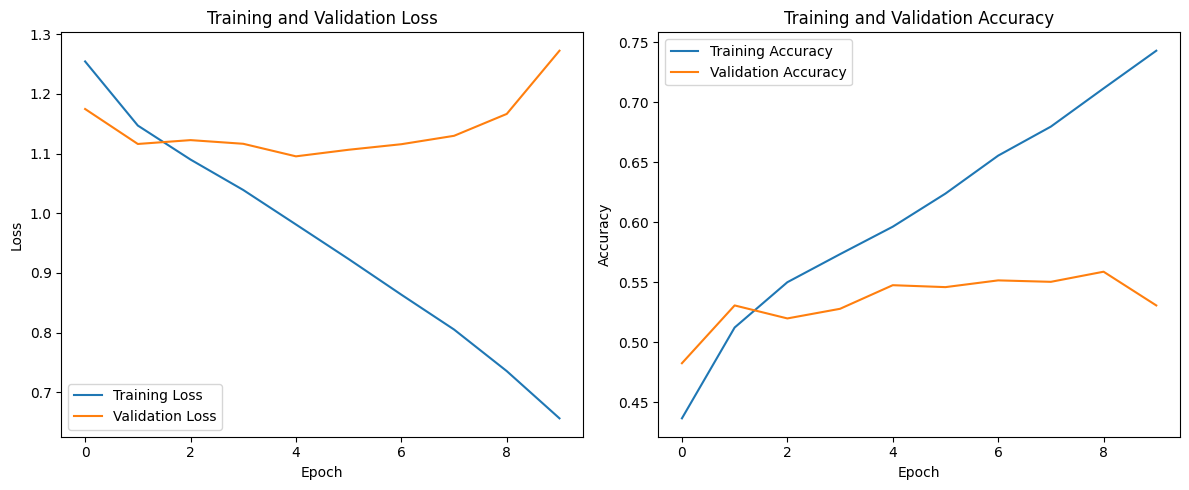

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# 1. Evaluate the trained model on the validation data
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# 2. Obtain the model's predictions on the validation set
y_pred_probs = model.predict(X_val)

# 3. Convert one-hot encoded true labels and predicted probabilities to class labels
y_true_labels = np.argmax(y_val, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Get class names from the label_encoder used earlier
class_names = label_encoder.classes_

# 5. Generate and print a classification report
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

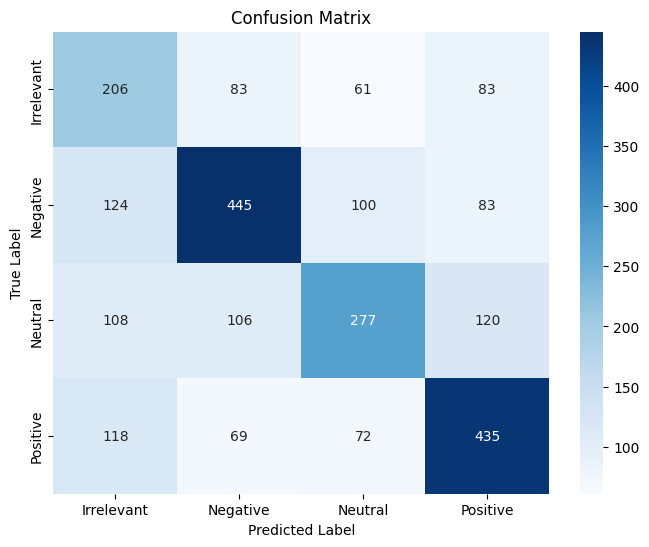

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The Updated GRU Model Architecture
The current model incorporates several key enhancements:

Embedding Layer: It now utilizes pre-trained GloVe embeddings (100-dimensional) to initialize the embedding layer. This layer is set to trainable=False, meaning the model leverages the rich semantic information captured by GloVe from a much larger corpus, rather than learning embeddings from scratch with our potentially limited dataset.
Bidirectional GRU Layer: The model uses a Bidirectional GRU layer with 128 units. This allows the network to process the input sequence in both forward and backward directions, capturing context from both past and future words in a sequence, which is highly beneficial for understanding nuanced sentiment.
Dropout Layer: A Dropout layer with a rate of 0.3 is placed after the GRU layer. This helps in regularizing the model by randomly setting a fraction of input units to zero during training, thereby preventing overfitting.
Dense Output Layer: A final Dense layer with a softmax activation function outputs the probabilities for each of the four sentiment classes (Irrelevant, Negative, Neutral, Positive).
Performance Improvement with Updates
Compared to the previous iteration where the model suffered from severe class imbalance and achieved a validation accuracy of roughly 30-31% by heavily defaulting to the 'Negative' class, the current model shows a significant improvement:

Overall Validation Accuracy: The model now achieves a validation accuracy of approximately 54.74% with a validation loss of 1.0954. This is a substantial improvement over the previous ~30% accuracy, indicating much better generalization.

Balanced Prediction Across Classes: The most crucial improvement is in the model's ability to differentiate between sentiment classes, thanks to the class weighting. Let's look at the classification report:

Irrelevant: Precision 0.37, Recall 0.48, F1-score 0.42
Negative: Precision 0.63, Recall 0.59, F1-score 0.61
Neutral: Precision 0.54, Recall 0.45, F1-score 0.49
Positive: Precision 0.60, Recall 0.63, F1-score 0.61
The F1-scores for 'Irrelevant', 'Neutral', and 'Positive' are no longer near zero, as they were previously. While 'Negative' still has the highest F1-score, the model is now making meaningful predictions for all classes, as evidenced by the non-zero precision and recall values across the board. The macro avg F1-score is 0.53, indicating a more balanced performance across classes.

Training Dynamics: The training history shows a steady decrease in loss and an increase in accuracy for both training and validation sets for the initial epochs, before EarlyStopping triggered. This suggests that the model is actively learning and making progress, rather than simply defaulting to a single class.

Remaining Challenges and Next Steps
While significantly improved, there's still room for further optimization:

Class-specific Performance: The 'Irrelevant' class still has relatively lower precision and F1-score. This could be due to its smaller support in the dataset or inherent ambiguity.
Overall Accuracy: An accuracy of 54.74% indicates that the model is correct slightly more than half the time. Further tuning of hyperparameters, exploring different pre-trained embeddings (e.g., domain-specific), or even more complex model architectures could yield better results.
Data Augmentation: For the 'Irrelevant' class, data augmentation techniques might be considered to provide the model with more diverse examples.
These updates have successfully transformed the model from one that was effectively guessing the majority class to one that can make meaningful, albeit imperfect, predictions across all sentiment categories.